# Lesson 3: Manual Hyperparameter Search


Самостоятельный ноутбук для ручного подбора гиперпараметров, сохранения результатов, модели и повторной проверки после загрузки.


In [1]:
from __future__ import annotations

import json
from datetime import datetime
from pathlib import Path
from typing import Any, cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import display
from sklearn.datasets import load_digits
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split

from students.kudryavcev.lesson3 import Exercise, Layer, LinearLayer, Model


In [2]:
PROJECT_DIR = Path("students/kudryavcev/lesson3")
RESULTS_DIR = PROJECT_DIR / "results"
MODELS_DIR = PROJECT_DIR / "models/manual"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
FINAL_SEED = 2026
N_CLASSES = 10


In [3]:
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1.0

X_train_norm = (X_train - mean) / std
X_val_norm = (X_val - mean) / std
X_test_norm = (X_test - mean) / std
X_trainval_norm = np.vstack([X_train_norm, X_val_norm])
y_trainval = np.concatenate([y_train, y_val])

print(
    f"Dataset split: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}"
)


Dataset split: train=1077, val=360, test=360


In [4]:
def build_model(
    hidden_layers: list[tuple[int, str]],
    *,
    input_dim: int,
    output_dim: int,
    seed: int,
) -> Model:
    rng = np.random.default_rng(seed)
    layers: list[Layer] = []
    current_dim = input_dim

    for units, activation in hidden_layers:
        layers.append(Exercise.create_linear_layer(current_dim, units, rng))
        if activation == "relu":
            layers.append(Exercise.create_relu_layer())
        elif activation == "sigmoid":
            layers.append(Exercise.create_sigmoid_layer())
        else:
            raise ValueError(f"Unsupported activation: {activation}")
        current_dim = units

    layers.append(Exercise.create_linear_layer(current_dim, output_dim, rng))
    return Exercise.create_model(*layers)


def predict_classes(model: Model, x: np.ndarray) -> np.ndarray:
    logits = model.forward(x)
    return np.argmax(logits, axis=1)


def evaluate_accuracy(model: Model, x: np.ndarray, y_true: np.ndarray) -> float:
    y_pred = predict_classes(model, x)
    return float(accuracy_score(y_true, y_pred))


def sanitize_name(value: str) -> str:
    chars: list[str] = []
    for char in value:
        if char.isalnum() or char in {'-', '_'}:
            chars.append(char)
        else:
            chars.append('_')
    return ''.join(chars)


def format_architecture_name(hidden_layers: list[tuple[int, str]]) -> str:
    parts = [f"{units}{activation[0]}" for units, activation in hidden_layers]
    return f"{len(hidden_layers)}L_" + '_'.join(parts)


def make_model_path(
    prefix: str,
    arch_name: str,
    *,
    lr: float,
    batch_size: int,
    epochs: int,
    accuracy: float,
) -> Path:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = (
        f"{timestamp}_{sanitize_name(prefix)}_{sanitize_name(arch_name)}_"
        f"lr{lr:g}_bs{batch_size}_ep{epochs}_acc{accuracy:.4f}.npz"
    )
    return MODELS_DIR / filename


def save_model_bundle(
    model: Model,
    filepath: Path,
    *,
    arch_name: str,
    config: list[tuple[int, str]],
    mean_vector: np.ndarray,
    std_vector: np.ndarray,
) -> None:
    payload: dict[str, Any] = {
        'arch_name': np.array(arch_name),
        'config': np.array(json.dumps(config)),
        'mean': mean_vector.astype(np.float32),
        'std': std_vector.astype(np.float32),
    }

    linear_idx = 0
    for layer in model.layers:
        if isinstance(layer, LinearLayer):
            payload[f'weight_{linear_idx}'] = layer.weights
            payload[f'bias_{linear_idx}'] = layer.bias
            linear_idx += 1

    np.savez(str(filepath), **payload)
    print(f"Saved model to {filepath}")


def load_model_bundle(filepath: Path, *, seed: int = 0) -> tuple[Model, dict[str, Any]]:
    data = np.load(filepath, allow_pickle=False)
    arch_name = str(data['arch_name'])
    config_raw = cast(list[list[Any]], json.loads(str(data['config'])))
    config = [(int(units), str(activation)) for units, activation in config_raw]
    mean_vector = data['mean'].astype(np.float32)
    std_vector = data['std'].astype(np.float32)

    model = build_model(
        config,
        input_dim=int(mean_vector.shape[0]),
        output_dim=N_CLASSES,
        seed=seed,
    )

    linear_idx = 0
    for layer in model.layers:
        if isinstance(layer, LinearLayer):
            layer.weights = data[f'weight_{linear_idx}'].astype(np.float32)
            layer.bias = data[f'bias_{linear_idx}'].astype(np.float32)
            linear_idx += 1

    metadata: dict[str, Any] = {
        'arch_name': arch_name,
        'config': config,
        'mean': mean_vector,
        'std': std_vector,
    }
    return model, metadata


def plot_confusion(y_true: np.ndarray, y_pred: np.ndarray, *, title: str) -> None:
    fig, ax = plt.subplots(figsize=(7, 7))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, cmap='Blues')
    ax.set_title(title)
    plt.tight_layout()
    if get_ipython() is not None:
        display(fig)
    plt.close(fig)


In [5]:
MANUAL_RESULTS_CSV = RESULTS_DIR / 'manual_results.csv'
MANUAL_BEST_JSON = RESULTS_DIR / 'manual_best.json'

manual_grid = {
    'architectures': [
        [(32, 'relu')],
        [(64, 'relu')],
        [(64, 'relu'), (32, 'relu')],
        [(128, 'relu'), (64, 'relu')],
    ],
    'lr': [0.05, 0.1],
    'batch_size': [32, 64],
    'epochs': [80, 120],
    'seed': [42, 2024],
}


def evaluate_manual_config(
    hidden_layers: list[tuple[int, str]],
    *,
    lr: float,
    batch_size: int,
    epochs: int,
    seed: int,
) -> float:
    model = build_model(
        hidden_layers,
        input_dim=int(X_train_norm.shape[1]),
        output_dim=N_CLASSES,
        seed=seed,
    )
    loss = Exercise.create_cross_entropy_loss()
    Exercise.train_model(
        model=model,
        loss=loss,
        x=X_train_norm,
        y=y_train,
        lr=lr,
        n_epoch=epochs,
        batch_size=batch_size,
        shuffle=True,
    )
    return evaluate_accuracy(model, X_val_norm, y_val)


records: list[dict[str, Any]] = []

for hidden_layers in manual_grid['architectures']:
    arch_name = format_architecture_name(hidden_layers)
    for lr in manual_grid['lr']:
        for batch_size in manual_grid['batch_size']:
            for epochs in manual_grid['epochs']:
                scores: list[float] = []
                for seed in manual_grid['seed']:
                    val_accuracy = evaluate_manual_config(
                        hidden_layers,
                        lr=lr,
                        batch_size=batch_size,
                        epochs=epochs,
                        seed=seed,
                    )
                    scores.append(val_accuracy)

                records.append(
                    {
                        'arch_name': arch_name,
                        'config': json.dumps(hidden_layers),
                        'lr': lr,
                        'batch_size': batch_size,
                        'epochs': epochs,
                        'seeds': json.dumps(manual_grid['seed']),
                        'mean_val_accuracy': float(np.mean(scores)),
                        'std_val_accuracy': float(np.std(scores)),
                    }
                )

manual_results = pd.DataFrame(records).sort_values(
    by=['mean_val_accuracy', 'std_val_accuracy'],
    ascending=[False, True],
    ignore_index=True,
)
manual_results.to_csv(MANUAL_RESULTS_CSV, index=False)
print(manual_results.head(10).to_string(index=False))


 arch_name                       config   lr  batch_size  epochs      seeds  mean_val_accuracy  std_val_accuracy
2L_64r_32r [[64, "relu"], [32, "relu"]] 0.10          32      80 [42, 2024]           0.981944          0.004167
2L_64r_32r [[64, "relu"], [32, "relu"]] 0.10          32     120 [42, 2024]           0.981944          0.004167
2L_64r_32r [[64, "relu"], [32, "relu"]] 0.10          64     120 [42, 2024]           0.981944          0.004167
    1L_64r               [[64, "relu"]] 0.10          64     120 [42, 2024]           0.981944          0.001389
2L_64r_32r [[64, "relu"], [32, "relu"]] 0.05          32     120 [42, 2024]           0.980556          0.005556
2L_64r_32r [[64, "relu"], [32, "relu"]] 0.10          64      80 [42, 2024]           0.980556          0.005556
    1L_64r               [[64, "relu"]] 0.10          32      80 [42, 2024]           0.980556          0.000000
    1L_64r               [[64, "relu"]] 0.10          32     120 [42, 2024]           0.980556  

Saved model to students/kudryavcev/lesson3/models/manual/20260406_154343_manual_2L_64r_32r_lr0.1_bs32_ep80_acc0.9694.npz


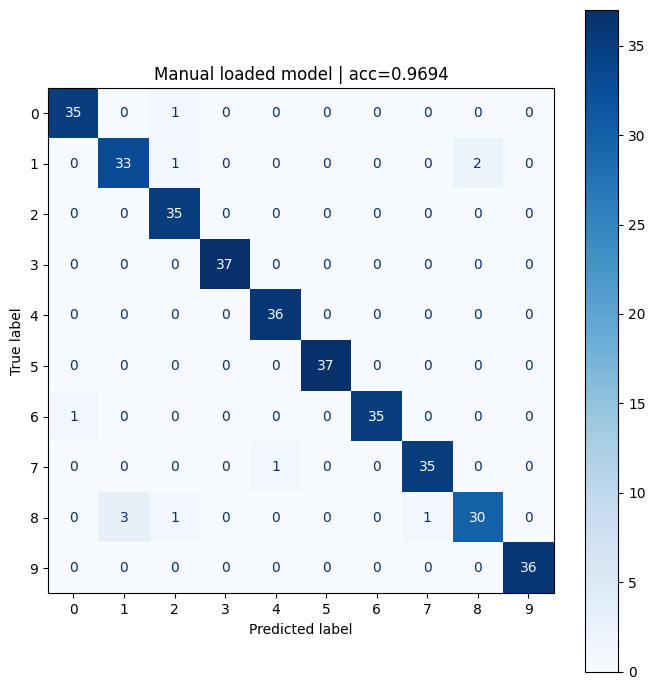

{
  "arch_name": "2L_64r_32r",
  "config": [
    [
      64,
      "relu"
    ],
    [
      32,
      "relu"
    ]
  ],
  "lr": 0.1,
  "batch_size": 32,
  "epochs": 80,
  "validation_mean_accuracy": 0.9819444444444445,
  "validation_std_accuracy": 0.004166666666666707,
  "model_path": "students/kudryavcev/lesson3/models/manual/20260406_154343_manual_2L_64r_32r_lr0.1_bs32_ep80_acc0.9694.npz",
  "test_accuracy": 0.9694444444444444,
  "loaded_test_accuracy": 0.9694444444444444
}


In [6]:
best_row = manual_results.iloc[0]
best_row_data = cast(dict[str, Any], best_row.to_dict())
best_config_raw = cast(list[list[Any]], json.loads(str(best_row_data['config'])))
best_config = [(int(units), str(activation)) for units, activation in best_config_raw]
best_arch_name = str(best_row_data['arch_name'])
best_lr = float(best_row_data['lr'])
best_batch_size = int(best_row_data['batch_size'])
best_epochs = int(best_row_data['epochs'])

final_manual_model = build_model(
    best_config,
    input_dim=int(X_trainval_norm.shape[1]),
    output_dim=N_CLASSES,
    seed=FINAL_SEED,
)
final_manual_loss = Exercise.create_cross_entropy_loss()
Exercise.train_model(
    model=final_manual_model,
    loss=final_manual_loss,
    x=X_trainval_norm,
    y=y_trainval,
    lr=best_lr,
    n_epoch=best_epochs,
    batch_size=best_batch_size,
    shuffle=True,
)

manual_test_pred = predict_classes(final_manual_model, X_test_norm)
manual_test_accuracy = float(accuracy_score(y_test, manual_test_pred))

manual_model_path = make_model_path(
    'manual',
    best_arch_name,
    lr=best_lr,
    batch_size=best_batch_size,
    epochs=best_epochs,
    accuracy=manual_test_accuracy,
)
save_model_bundle(
    final_manual_model,
    manual_model_path,
    arch_name=best_arch_name,
    config=best_config,
    mean_vector=mean,
    std_vector=std,
)

loaded_manual_model, loaded_manual_metadata = load_model_bundle(
    manual_model_path,
    seed=FINAL_SEED,
)
loaded_mean = cast(np.ndarray, loaded_manual_metadata['mean'])
loaded_std = cast(np.ndarray, loaded_manual_metadata['std'])
X_test_from_file = (X_test - loaded_mean) / loaded_std
manual_loaded_pred = predict_classes(loaded_manual_model, X_test_from_file)
manual_loaded_test_accuracy = float(accuracy_score(y_test, manual_loaded_pred))
plot_confusion(
    y_test,
    manual_loaded_pred,
    title=f'Manual loaded model | acc={manual_loaded_test_accuracy:.4f}',
)

manual_best_payload = {
    'arch_name': best_arch_name,
    'config': best_config,
    'lr': best_lr,
    'batch_size': best_batch_size,
    'epochs': best_epochs,
    'validation_mean_accuracy': float(best_row_data['mean_val_accuracy']),
    'validation_std_accuracy': float(best_row_data['std_val_accuracy']),
    'model_path': str(manual_model_path),
    'test_accuracy': manual_test_accuracy,
    'loaded_test_accuracy': manual_loaded_test_accuracy,
}
MANUAL_BEST_JSON.write_text(
    json.dumps(manual_best_payload, ensure_ascii=False, indent=2),
    encoding='utf-8',
)

print(json.dumps(manual_best_payload, ensure_ascii=False, indent=2))
